# 04 — Diversity Analysis

Alpha diversity: richness and evenness within each sample. Do RA patients
have less diverse gut communities?

Beta diversity: dissimilarity between samples. Do RA and HC communities
separate as groups?

Primary cohort: Beijing (n=1,928). Non-Beijing (n=310) held for replication.


In [2]:
from scipy.stats import mannwhitneyu
from skbio.diversity.alpha import shannon, simpson, observed_features
from skbio.stats.distance import DistanceMatrix, permanova
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from config import PARAMS, PATHS

PROCESSED = "../data/processed/"
FIGURES   = "../results/figures/"

# Load everything notebook 02 produced
counts = pd.read_csv(PROCESSED + "genus_counts.csv", index_col="sample_id")
clr_df = pd.read_csv(PROCESSED + "genus_clr.csv",    index_col="sample_id")
meta   = pd.read_csv(PROCESSED + "metadata.csv",     index_col="sample_id")
tax    = pd.read_csv(PROCESSED + "taxonomy.csv",     index_col="asv_id")

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Rebuild Beijing / non-Beijing split
beijing_samples = meta.index[meta["location"] == "Beijing"]
other_samples   = meta.index[meta["location"] != "Beijing"]

meta_bj   = meta.loc[beijing_samples]
counts_bj = counts.loc[beijing_samples]
clr_bj    = clr_df.loc[beijing_samples]

meta_other   = meta.loc[other_samples]
counts_other = counts.loc[other_samples]
clr_other    = clr_df.loc[other_samples]

print(f"Beijing (primary):    {len(beijing_samples)}")
print(meta_bj["disease_status"].value_counts().to_string())
print(f"\nNon-Beijing (replication): {len(other_samples)}")
print(meta_other["disease_status"].value_counts().to_string())

Beijing (primary):    1928
disease_status
HC    1109
RA     819

Non-Beijing (replication): 310
disease_status
RA    215
HC     95


In [3]:
# Compute alpha diversity on count data (not CLR)
alpha = pd.DataFrame({
    "shannon":  counts_bj.apply(lambda row: shannon(row.values), axis=1),
    "simpson":  counts_bj.apply(lambda row: simpson(row.values), axis=1),
    "observed": counts_bj.apply(lambda row: observed_features(row.values), axis=1),
})

alpha = alpha.join(meta_bj["disease_status"])

print(alpha.groupby("disease_status").describe().round(3).T)

disease_status        HC       RA
shannon  count  1109.000  819.000
         mean      2.695    2.597
         std       0.534    0.452
         min       0.034    0.391
         25%       2.473    2.315
         50%       2.786    2.632
         75%       3.042    2.923
         max       3.663    3.483
simpson  count  1109.000  819.000
         mean      0.859    0.858
         std       0.119    0.078
         min       0.008    0.166
         25%       0.842    0.824
         50%       0.889    0.877
         75%       0.919    0.912
         max       0.962    0.956
observed count  1109.000  819.000
         mean     53.854   47.836
         std      14.788   14.306
         min       8.000    8.000
         25%      45.000   37.000
         50%      56.000   47.000
         75%      65.000   59.000
         max      85.000   80.000


In [4]:
def cliffs_delta(x, y):
    """
    Non-parametric effect size: P(x > y) - P(x < y), range -1 to 1.
    Thresholds: |d| < 0.147 negligible, < 0.33 small, < 0.474 medium, else large.
    """
    x, y = np.asarray(x), np.asarray(y)
    n_greater = sum((xi > y).sum() for xi in x)
    n_less    = sum((xi < y).sum() for xi in x)
    return (n_greater - n_less) / (len(x) * len(y))


def interpret_delta(d):
    ad = abs(d)
    if ad < 0.147: return "negligible"
    if ad < 0.330: return "small"
    if ad < 0.474: return "medium"
    return "large"


results = []
for metric in ["shannon", "simpson", "observed"]:
    hc = alpha.loc[alpha.disease_status == "HC", metric]
    ra = alpha.loc[alpha.disease_status == "RA", metric]

    stat, p = mannwhitneyu(hc, ra)
    d = cliffs_delta(ra, hc)          # positive = higher in RA

    results.append({
        "metric":      metric,
        "HC_median":   hc.median(),
        "RA_median":   ra.median(),
        "p_value":     p,
        "cliffs_d":    d,
        "effect_size": interpret_delta(d)
    })

alpha_results = pd.DataFrame(results)
print(alpha_results.round(4).to_string(index=False))

  metric  HC_median  RA_median  p_value  cliffs_d effect_size
 shannon     2.7855     2.6316   0.0000   -0.1721       small
 simpson     0.8886     0.8773   0.0001   -0.1053  negligible
observed    56.0000    47.0000   0.0000   -0.2518       small


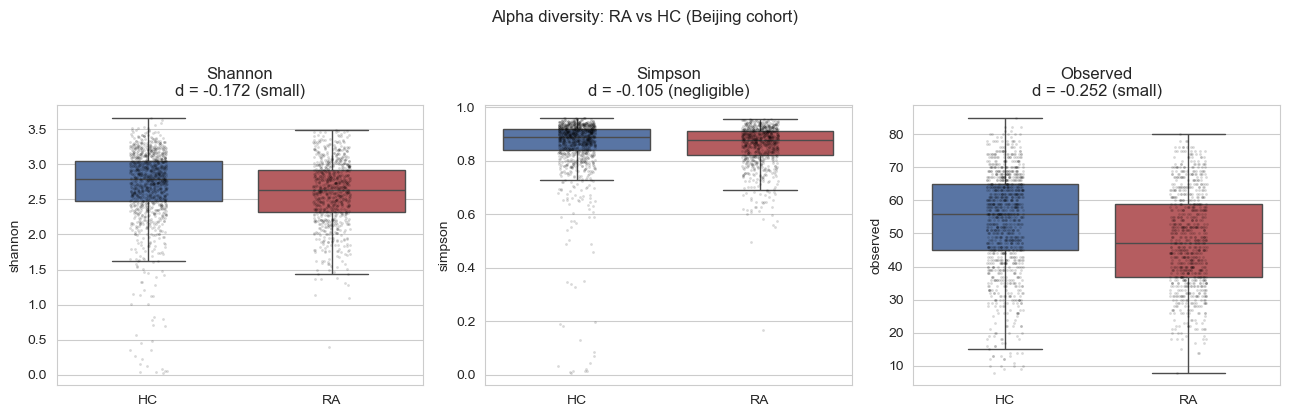

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric in zip(axes, ["shannon", "simpson", "observed"]):
    sns.boxplot(data=alpha, x="disease_status", y=metric,
                hue="disease_status", legend=False,
                palette={"HC": "#4C72B0", "RA": "#C44E52"},
                showfliers=False, ax=ax)
    sns.stripplot(data=alpha, x="disease_status", y=metric,
                  color="black", alpha=0.15, size=2, ax=ax)

    row = alpha_results[alpha_results.metric == metric].iloc[0]
    ax.set_title(f"{metric.capitalize()}\nd = {row.cliffs_d:.3f} ({row.effect_size})")
    ax.set_xlabel("")

plt.suptitle("Alpha diversity: RA vs HC (Beijing cohort)", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES + "alpha_diversity.png", dpi=200, bbox_inches="tight")
plt.show()

alpha_results.to_csv("../results/tables/alpha_diversity_stats.csv", index=False)

In [6]:
# Aitchison distance = Euclidean on CLR
dist_condensed = pdist(clr_bj.values, metric="euclidean")
dist_square    = squareform(dist_condensed)

dm = DistanceMatrix(dist_square, ids=clr_bj.index.tolist())

print(f"Distance matrix: {dm.shape}")
print(f"Mean distance:   {dist_condensed.mean():.2f}")
print(f"Range:           {dist_condensed.min():.2f} to {dist_condensed.max():.2f}")

Distance matrix: (1928, 1928)
Mean distance:   27.28
Range:           6.08 to 42.68


PC1: 16.1% of variance
PC2: 6.3%
First 5 PCs: 33.7% cumulative


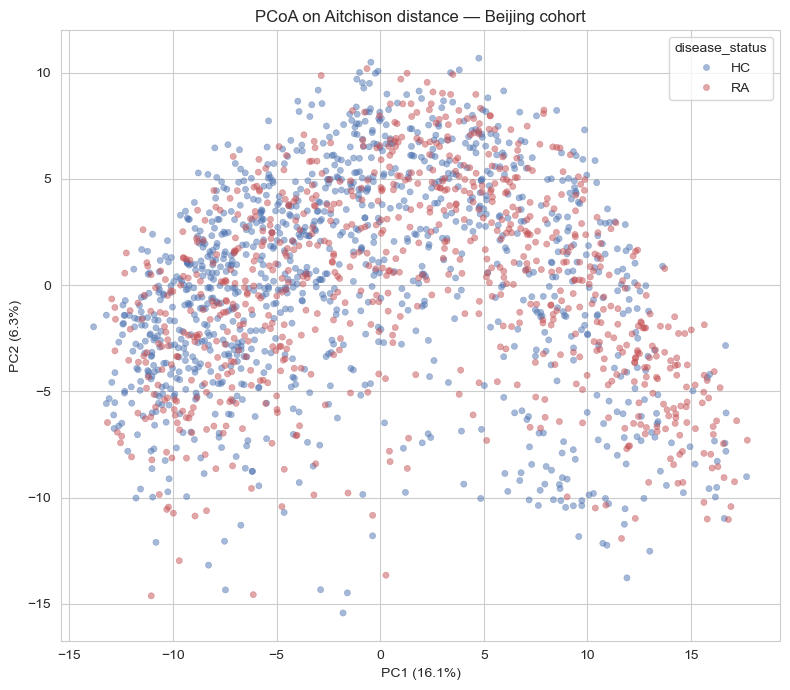

In [7]:
pca = PCA(n_components=5)
coords = pca.fit_transform(clr_bj.values)

pcoa_df = pd.DataFrame(
    coords[:, :2],
    index=clr_bj.index,
    columns=["PC1", "PC2"]
).join(meta_bj[["disease_status"]])

var_explained = pca.explained_variance_ratio_ * 100
print(f"PC1: {var_explained[0]:.1f}% of variance")
print(f"PC2: {var_explained[1]:.1f}%")
print(f"First 5 PCs: {var_explained[:5].sum():.1f}% cumulative")

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", hue="disease_status",
                palette={"HC": "#4C72B0", "RA": "#C44E52"},
                alpha=0.5, s=20, ax=ax, edgecolor=None)
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}%)")
ax.set_title("PCoA on Aitchison distance — Beijing cohort")
plt.tight_layout()
plt.savefig(FIGURES + "pcoa_disease.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
print(pcoa_df.loc[["HC0745"]])
print("\nPC1 percentile:", (pcoa_df.PC1 < pcoa_df.loc["HC0745","PC1"]).mean().round(3))
print("PC2 percentile:", (pcoa_df.PC2 < pcoa_df.loc["HC0745","PC2"]).mean().round(3))

                PC1       PC2 disease_status
sample_id                                   
HC0745     7.080813 -6.330604             HC

PC1 percentile: 0.77
PC2 percentile: 0.114


In [9]:
# PERMANOVA: do RA and HC communities differ?
grouping = meta_bj.loc[dm.ids, "disease_status"]

result = permanova(dm, grouping, permutations=999)
print(result)

# R-squared: proportion of variance explained by disease status
f_stat = result["test statistic"]
n = len(dm.ids)
r2 = (f_stat * 1) / (f_stat * 1 + (n - 2))
print(f"\nR² = {r2:.4f}  ({r2*100:.2f}% of variance explained by disease status)")

AssertionError: 

In [10]:
 grouping = meta_bj.loc[list(dm.ids), "disease_status"]

result = permanova(dm, grouping, permutations=999)
print(result)

f_stat = result["test statistic"]
n = len(dm.ids)
r2 = (f_stat * 1) / (f_stat * 1 + (n - 2))
print(f"\nR² = {r2:.4f}  ({r2*100:.2f}% of variance explained by disease status)")

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1928
number of groups                  2
test statistic            17.739502
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

R² = 0.0091  (0.91% of variance explained by disease status)


In [11]:
# How much variance does recruitment site explain, for comparison?
dist_all = squareform(pdist(clr_df.values, metric="euclidean"))
dm_all = DistanceMatrix(dist_all, ids=clr_df.index.tolist())

loc_group = meta.loc[list(dm_all.ids), "location"]
res_loc = permanova(dm_all, loc_group, permutations=999)
print(res_loc)

f = res_loc["test statistic"]
n = len(dm_all.ids)
k = meta["location"].nunique()
r2_loc = (f * (k-1)) / (f * (k-1) + (n - k))
print(f"\nLocation R² = {r2_loc:.4f} ({r2_loc*100:.2f}%)")

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    2238
number of groups                  5
test statistic             4.632214
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

Location R² = 0.0082 (0.82%)


In [12]:
from skbio.stats.distance import permdisp

disp = permdisp(dm, grouping, permutations=999)
print(disp)

method name               PERMDISP
test statistic name        F-value
sample size                   1928
number of groups                 2
test statistic            2.611334
p-value                      0.101
number of permutations         999
Name: PERMDISP results, dtype: object
